In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv(
    r"C:\Users\shita\OneDrive\Desktop\CodeAlpha_EDA\netflix_titles.csv"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 8807
Columns: 12


In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


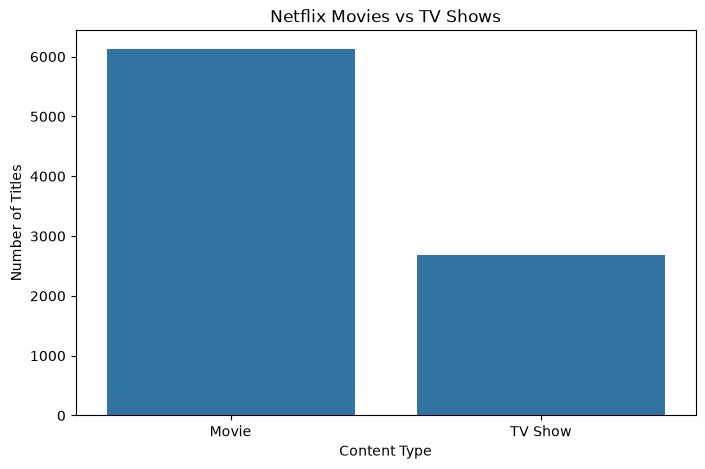

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='type')

plt.title('Netflix Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.savefig(
    r"C:\Users\shita\OneDrive\Desktop\CodeAlpha_EDA\visualizations_task3\movies_vs_tv_shows.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

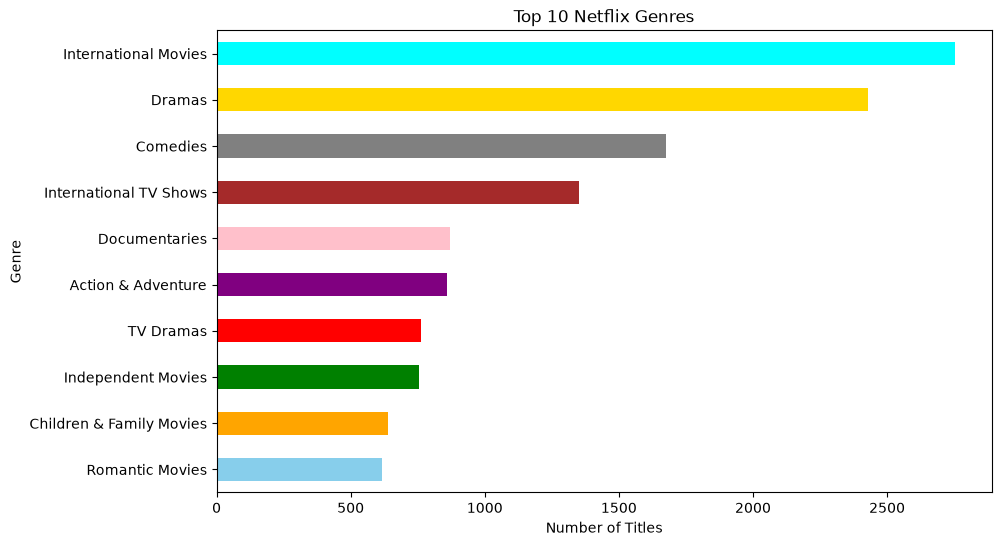

In [6]:
genre_counts = (
    df['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

genre_counts.sort_values().plot(
    kind='barh',
    color=['skyblue', 'orange', 'green', 'red', 'purple',
           'pink', 'brown', 'gray', 'gold', 'cyan']
)

plt.title('Top 10 Netflix Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.savefig(
    r"C:\Users\shita\OneDrive\Desktop\CodeAlpha_EDA\visualizations_task3\top_10_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

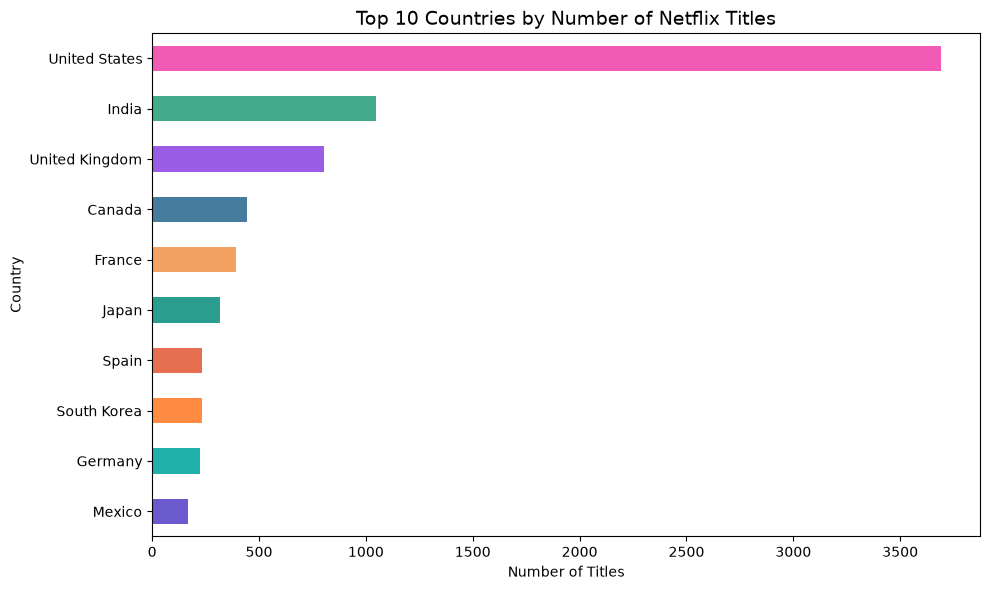

In [9]:
country_counts = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

country_counts.sort_values().plot(
    kind='barh',
    color=[
        '#6A5ACD',
        '#20B2AA',
        '#FF8C42',
        '#E76F51',
        '#2A9D8F',
        '#F4A261',
        '#457B9D',
        '#9B5DE5',
        '#43AA8B',
        '#F15BB5'
    ]
)

plt.title('Top 10 Countries by Number of Netflix Titles', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.tight_layout()

plt.savefig(
    r"C:\Users\shita\OneDrive\Desktop\CodeAlpha_EDA\visualizations_task3\top_10_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

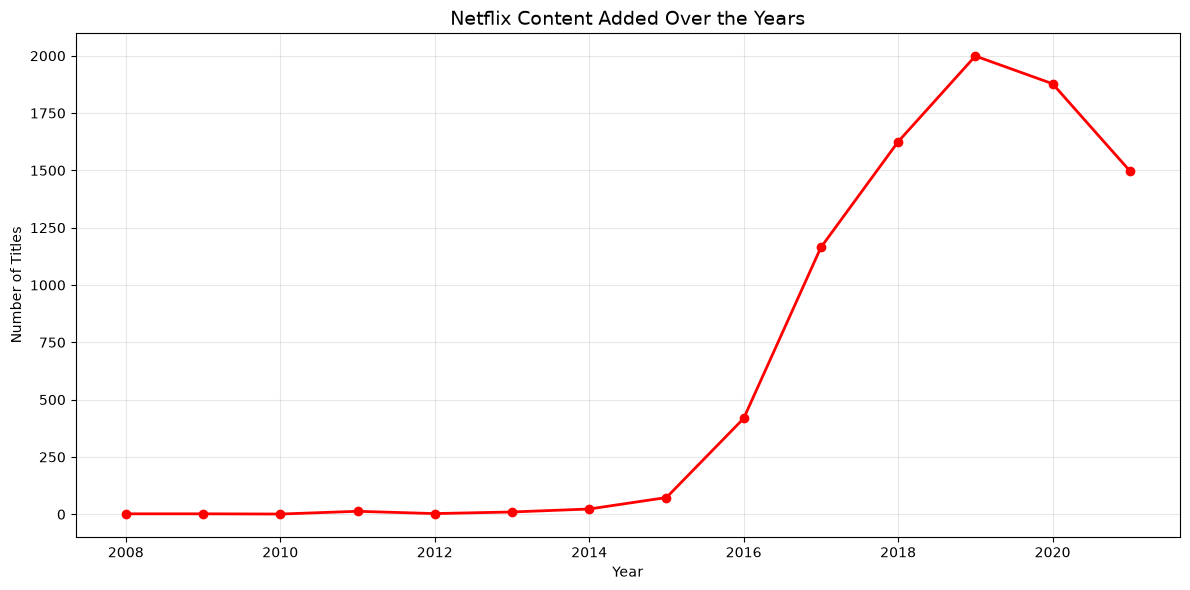

In [11]:
content_added = (
    pd.to_datetime(df['date_added'], errors='coerce')
    .dt.year
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    content_added.index,
    content_added.values,
    marker='o',
    linewidth=2, color='red'
)

plt.title('Netflix Content Added Over the Years', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    r"C:\Users\shita\OneDrive\Desktop\CodeAlpha_EDA\visualizations_task3\content_added_over_years.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

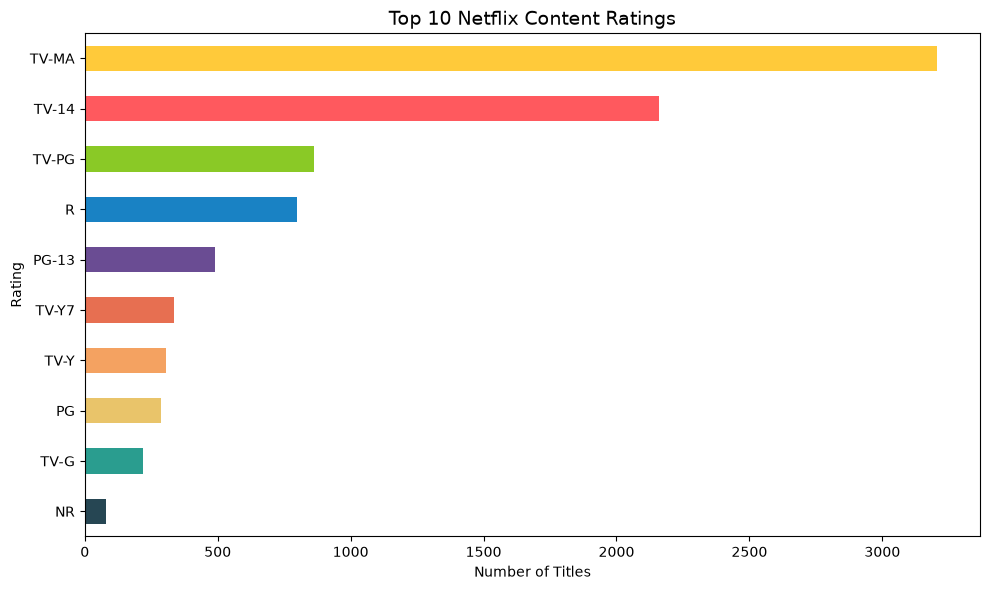

In [12]:
rating_counts = df['rating'].value_counts().head(10)

plt.figure(figsize=(10, 6))

rating_counts.sort_values().plot(
    kind='barh',
    color=[
        '#264653',
        '#2A9D8F',
        '#E9C46A',
        '#F4A261',
        '#E76F51',
        '#6A4C93',
        '#1982C4',
        '#8AC926',
        '#FF595E',
        '#FFCA3A'
    ]
)

plt.title('Top 10 Netflix Content Ratings', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('Rating')

plt.tight_layout()

plt.savefig(
    r"C:\Users\shita\OneDrive\Desktop\CodeAlpha_EDA\visualizations_task3\ratings_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

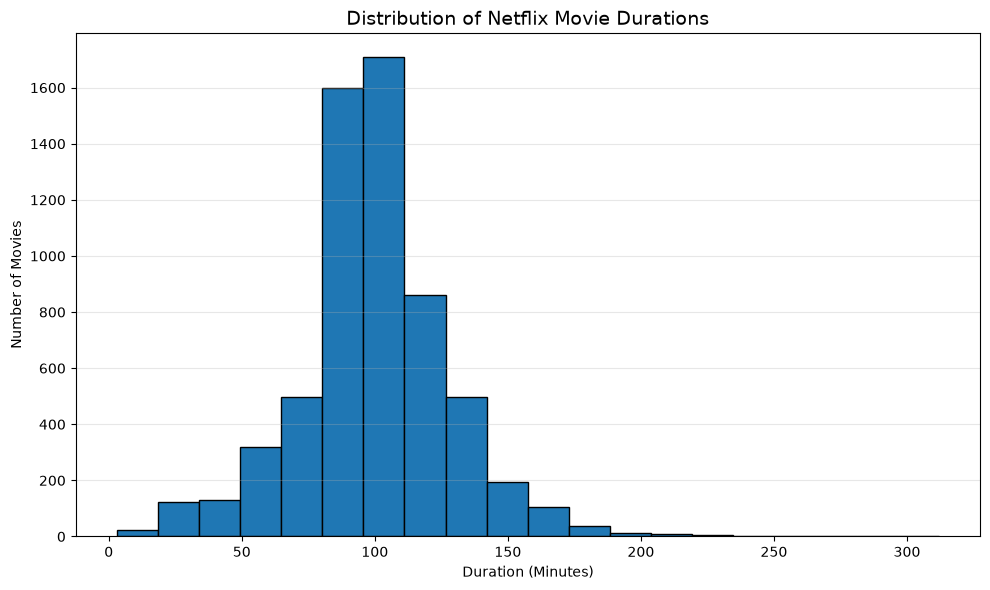

In [15]:
# Select only Movies
movies = df[df['type'] == 'Movie'].copy()

# Extract duration in minutes
movies['duration_minutes'] = (
    movies['duration']
    .str.extract(r'(\d+)')
    .astype(float)
)

plt.figure(figsize=(10, 6))

plt.hist(
    movies['duration_minutes'].dropna(),
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of Netflix Movie Durations', fontsize=14)
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    r"C:\Users\shita\OneDrive\Desktop\CodeAlpha_EDA\visualizations_task3\movie_duration_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

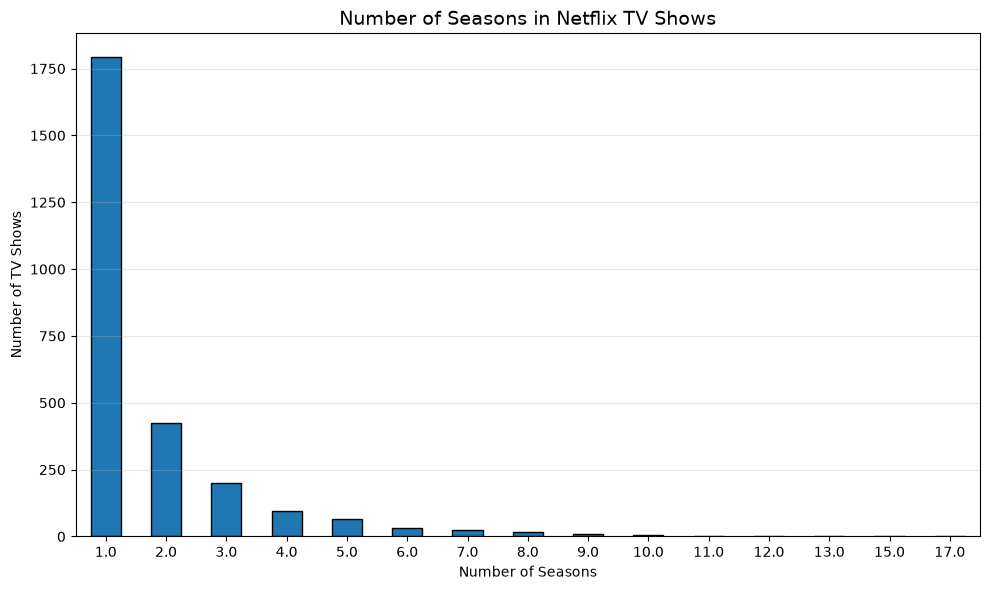

In [16]:
# Select only TV Shows
tv_shows = df[df['type'] == 'TV Show'].copy()

# Extract number of seasons
tv_shows['seasons'] = (
    tv_shows['duration']
    .str.extract(r'(\d+)')
    .astype(float)
)

season_counts = tv_shows['seasons'].value_counts().sort_index()

plt.figure(figsize=(10, 6))

season_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Number of Seasons in Netflix TV Shows', fontsize=14)
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    r"C:\Users\shita\OneDrive\Desktop\CodeAlpha_EDA\visualizations_task3\tv_show_seasons.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

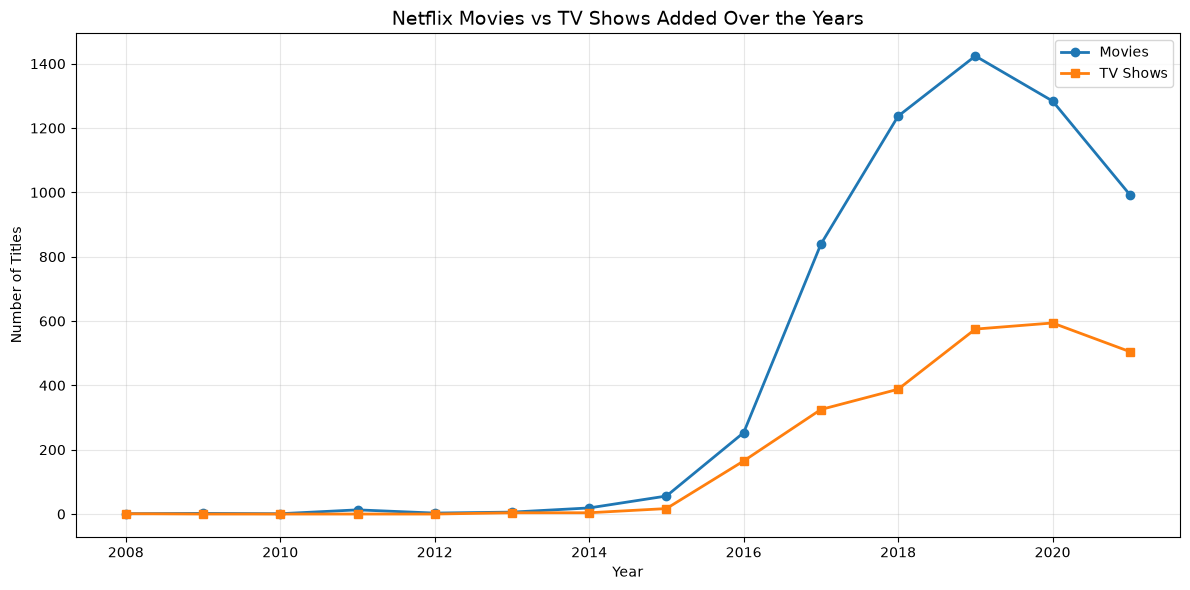

In [17]:
# Create year from date_added
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

# Count Movies and TV Shows by year
year_type = (
    df.dropna(subset=['year_added'])
      .groupby(['year_added', 'type'])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(12, 6))

plt.plot(
    year_type.index,
    year_type['Movie'],
    marker='o',
    linewidth=2,
    label='Movies'
)

plt.plot(
    year_type.index,
    year_type['TV Show'],
    marker='s',
    linewidth=2,
    label='TV Shows'
)

plt.title('Netflix Movies vs TV Shows Added Over the Years', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    r"C:\Users\shita\OneDrive\Desktop\CodeAlpha_EDA\visualizations_task3\movies_vs_tv_shows_over_years.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

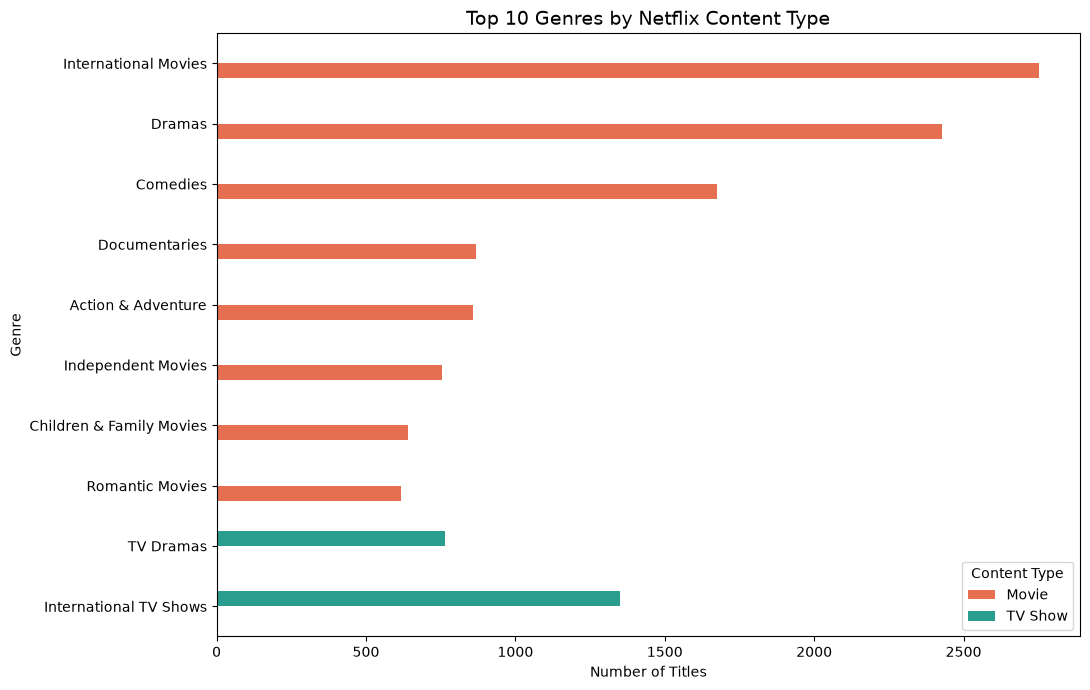

In [18]:
# Split genres and create separate rows
genre_df = df[['type', 'listed_in']].dropna().copy()

genre_df['listed_in'] = genre_df['listed_in'].str.split(', ')

genre_df = genre_df.explode('listed_in')

# Get top 10 overall genres
top_genres = genre_df['listed_in'].value_counts().head(10).index

# Keep only top 10 genres
genre_type_counts = (
    genre_df[genre_df['listed_in'].isin(top_genres)]
    .groupby(['listed_in', 'type'])
    .size()
    .unstack(fill_value=0)
)

# Plot
genre_type_counts.sort_values(
    by='Movie',
    ascending=True
).plot(
    kind='barh',
    figsize=(11, 7),
    color=['#E76F51', '#2A9D8F']
)

plt.title('Top 10 Genres by Netflix Content Type', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.legend(title='Content Type')
plt.tight_layout()

plt.savefig(
    r"C:\Users\shita\OneDrive\Desktop\CodeAlpha_EDA\visualizations_task3\top_genres_by_content_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

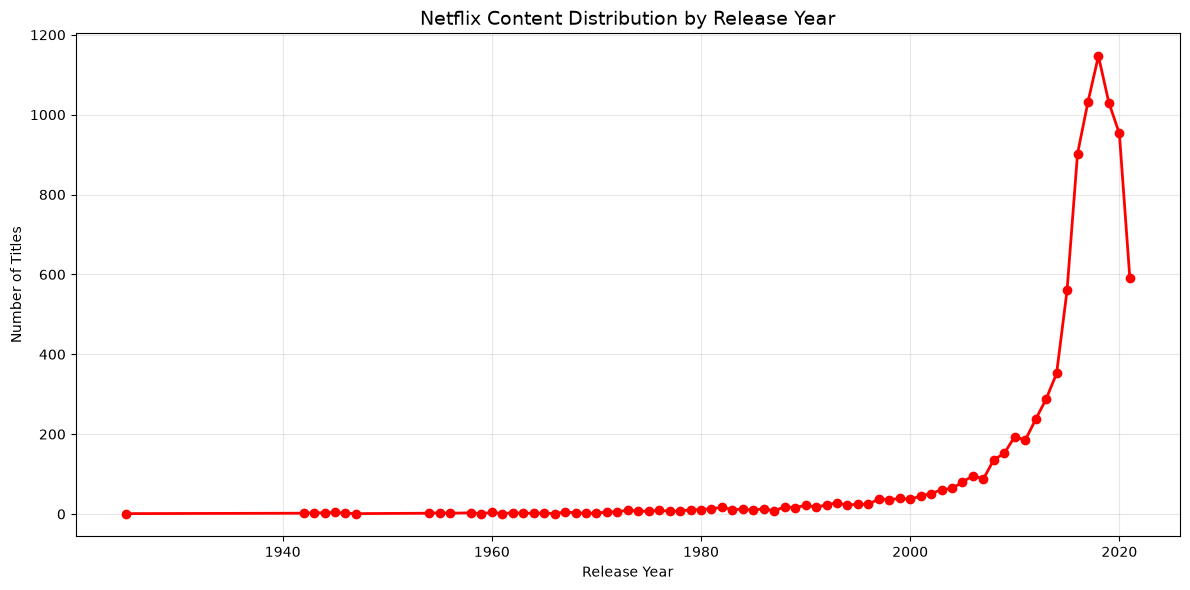

In [20]:
release_year_counts = (
    df['release_year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    release_year_counts.index,
    release_year_counts.values,
    marker='o',
    linewidth=2, color='red'
)

plt.title('Netflix Content Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    r"C:\Users\shita\OneDrive\Desktop\CodeAlpha_EDA\visualizations_task3\content_by_release_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insights from Data Visualizations

- Movies are significantly more common than TV Shows on Netflix.
- The most common Netflix genres are concentrated around popular entertainment categories.
- A small number of countries contribute a large share of Netflix titles.
- Netflix content additions increased significantly during the later years of the dataset.
- The ratings distribution shows that some content ratings are much more common than others.
- Most Netflix movies fall within a moderate duration range.
- Most Netflix TV Shows have a relatively small number of seasons.
- Movies generally have a higher count than TV Shows across the years.
- Genre distribution varies between Movies and TV Shows.
- The release-year analysis shows how Netflix's content library is distributed across different production years.
- 

## Conclusion

The Netflix dataset was analyzed using Python, Pandas, Matplotlib, and Seaborn. 
Different visualizations were created to understand content types, genres, countries, 
ratings, movie durations, TV show seasons, and yearly trends.

These visualizations make the dataset easier to understand and help identify 
important patterns and trends in Netflix's content library.